# Specialization Retention Results

This notebook ingests specialization retention eval outputs and builds tables and plots for FedAvg and Bank-per-client.

Expected structure (from run_local_individual_specialization_pipeline.sh):
- individual_results/<pipe_id>/global/spec_<exp>_<dataset>/<dataset>/<eval_id>/.../eval_result/accuracies_*__<dataset>.json

If you ran a different pipeline or moved results, update RUN_DIR below.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('.').resolve()
RUN_DIR_OVERRIDE = ''  # set to a specific run directory if needed

def find_results_root(candidates):
    for cand in candidates:
        if (cand / 'individual_results').exists():
            return cand
    return None

def latest_specialization_run(root: Path):
    results_root = root / 'individual_results'
    candidates = sorted(results_root.glob('individual_specialization_*'),
                        key=lambda p: p.stat().st_mtime)
    if not candidates:
        return None
    # Prefer a run that already has eval outputs.
    for cand in reversed(candidates):
        if any(cand.rglob('accuracies_*__*.json')):
            return cand
    return candidates[-1]

CANDIDATE_ROOTS = [
    ROOT,
    ROOT / 'FTL',
    Path('/home/heck2/sbhansali8/FTL'),
]
RESULTS_ROOT = find_results_root(CANDIDATE_ROOTS)
if RESULTS_ROOT is None:
    raise FileNotFoundError('Could not find an individual_results directory under candidate roots.')

if RUN_DIR_OVERRIDE:
    RUN_DIR = Path(RUN_DIR_OVERRIDE).expanduser().resolve()
else:
    RUN_DIR = latest_specialization_run(RESULTS_ROOT)
    if RUN_DIR is None:
        raise FileNotFoundError('No individual_specialization_* runs found under individual_results/.')

RUN_DIR = RUN_DIR.resolve()
if RUN_DIR.name == 'global':
    GLOBAL_DIR = RUN_DIR
    RUN_DIR = RUN_DIR.parent
elif (RUN_DIR / 'global').exists():
    GLOBAL_DIR = RUN_DIR / 'global'
else:
    GLOBAL_DIR = RUN_DIR

print(f'ROOT={ROOT}')
print(f'RESULTS_ROOT={RESULTS_ROOT}')
print(f'RUN_DIR={RUN_DIR}')
print(f'GLOBAL_DIR={GLOBAL_DIR}')


ROOT=/home/heck2/sbhansali8/FTL
RESULTS_ROOT=/home/heck2/sbhansali8/FTL
RUN_DIR=/home/heck2/sbhansali8/FTL/individual_results/individual_specialization_20260121_182914_18926
GLOBAL_DIR=/home/heck2/sbhansali8/FTL/individual_results/individual_specialization_20260121_182914_18926/global


In [2]:
DATASETS = ['gsm8k', 'hellaswag', 'xsum', 'hotpotqa', 'mbpp']
METHODS = ['fedavg', 'bank_perclient']
PRIMARY_METRICS = {
    'gsm8k': 'weighted_accuracy',
    'hellaswag': 'weighted_accuracy',
    'xsum': 'rougeL_f1',
    'hotpotqa': 'f1',
    'mbpp': 'pass@1',
}

def find_latest_accuracy_file(global_dir: Path, method: str, dataset: str):
    base = global_dir / f'spec_{method}_{dataset}' / dataset
    matches = []
    if base.exists():
        matches = list(base.rglob(f'accuracies_*__{dataset}.json'))
    if not matches:
        matches = [p for p in global_dir.rglob(f'accuracies_*__{dataset}.json')
                   if f'spec_{method}_{dataset}' in p.as_posix()]
    if not matches:
        return None
    matches.sort(key=lambda p: p.stat().st_mtime)
    return matches[-1]


In [3]:
records = []
missing = []

for method in METHODS:
    for dataset in DATASETS:
        path = find_latest_accuracy_file(GLOBAL_DIR, method, dataset)
        if path is None:
            missing.append({'method': method, 'dataset': dataset})
            continue
        with open(path, 'r', encoding='utf-8') as f:
            payload = json.load(f)
        total = payload.get('total_examples')
        for key in ['weighted_accuracy', 'rougeL_f1', 'em', 'f1', 'pass@1']:
            if key in payload:
                records.append({
                    'method': method,
                    'dataset': dataset,
                    'metric': key,
                    'value': payload[key],
                    'total_examples': total,
                    'path': str(path),
                })

full_df = pd.DataFrame(records)
missing_df = pd.DataFrame(missing)

display(full_df)
if not missing_df.empty:
    print('Missing results:')
    display(missing_df)


,method,dataset,metric,value,total_examples,path
0,fedavg,hellaswag,weighted_accuracy,0.520000,100,/home/heck2/sbhansali8/FTL/individual_results/...
1,fedavg,xsum,rougeL_f1,0.151476,100,/home/heck2/sbhansali8/FTL/individual_results/...
2,fedavg,hotpotqa,em,0.000000,100,/home/heck2/sbhansali8/FTL/individual_results/...
3,fedavg,hotpotqa,f1,0.095165,100,/home/heck2/sbhansali8/FTL/individual_results/...
4,fedavg,mbpp,pass@1,0.020000,100,/home/heck2/sbhansali8/FTL/individual_results/...
5,bank_perclient,hellaswag,weighted_accuracy,0.340000,100,/home/heck2/sbhansali8/FTL/individual_results/...
6,bank_perclient,xsum,rougeL_f1,0.160757,100,/home/heck2/sbhansali8/FTL/individual_results/...
7,bank_perclient,hotpotqa,em,0.000000,100,/home/heck2/sbhansali8/FTL/individual_results/...
8,bank_perclient,hotpotqa,f1,0.104488,100,/home/heck2/sbhansali8/FTL/individual_results/...
9,bank_perclient,mbpp,pass@1,0.020000,100,/home/heck2/sbhansali8/FTL/individual_results/...


Missing results:


,method,dataset
0,fedavg,gsm8k
1,bank_perclient,gsm8k


In [4]:
if full_df.empty:
    print('No results found yet. Check RUN_DIR/GLOBAL_DIR and eval completion.')
else:
    primary_rows = []
    for dataset, metric in PRIMARY_METRICS.items():
        for method in METHODS:
            subset = full_df[(full_df['dataset'] == dataset) & (full_df['method'] == method) & (full_df['metric'] == metric)]
            if subset.empty:
                continue
            row = subset.iloc[0].to_dict()
            primary_rows.append(row)

    primary_df = pd.DataFrame(primary_rows)
    if not primary_df.empty:
        pivot = primary_df.pivot(index='dataset', columns='method', values='value')
        pivot = pivot.reindex(DATASETS)
        display(pivot)

        totals = primary_df[['dataset', 'method', 'total_examples']].drop_duplicates()
        totals_pivot = totals.pivot(index='dataset', columns='method', values='total_examples').reindex(DATASETS)
        display(totals_pivot)
    else:
        print('No primary metrics found yet.')


method,bank_perclient,fedavg
dataset,,
gsm8k,NaN,NaN
hellaswag,0.340000,0.520000
xsum,0.160757,0.151476
hotpotqa,0.104488,0.095165
mbpp,0.020000,0.020000


method,bank_perclient,fedavg
dataset,,
gsm8k,NaN,NaN
hellaswag,100.0,100.0
xsum,100.0,100.0
hotpotqa,100.0,100.0
mbpp,100.0,100.0


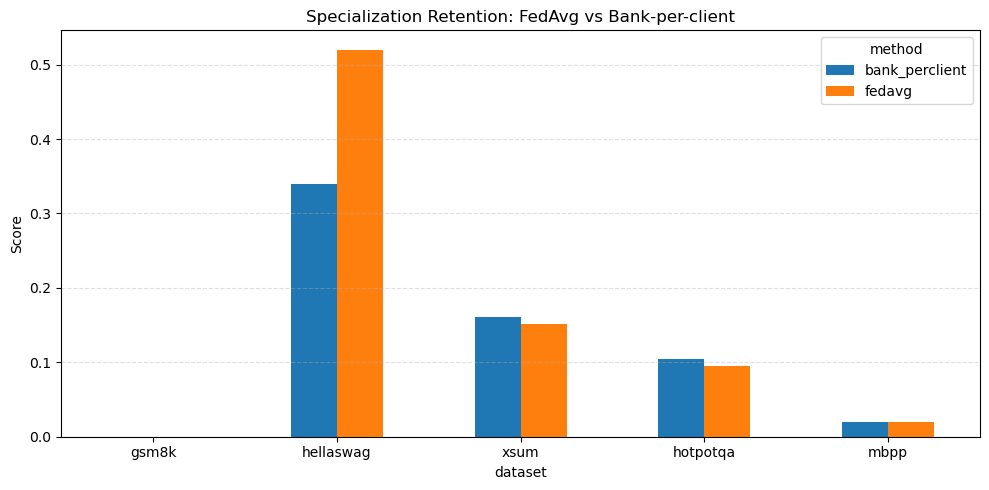

In [5]:
if 'primary_df' in globals() and not primary_df.empty:
    plot_df = primary_df.pivot(index='dataset', columns='method', values='value').reindex(DATASETS)
    ax = plot_df.plot(kind='bar', figsize=(10, 5), rot=0)
    ax.set_ylabel('Score')
    ax.set_title('Specialization Retention: FedAvg vs Bank-per-client')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


Notes:
- gsm8k eval outputs do not include total_examples in the JSON; totals table may be blank there.
- For hotpotqa, both em and f1 are recorded; the primary table uses f1 by default.
